# EDA, probabilidad de inserción laboral Panamá

In [179]:
!pip install -q pandas matplotlib seaborn pyreadstat
!pip install -q itables
!pip install linearmodels

In [180]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import warnings
from itables import show
import statsmodels.api as sm

warnings.filterwarnings('ignore')

In [181]:
# Subir archivo manualmente

from google.colab import files
uploaded = files.upload()

Saving 240322base de datos completa.sav to 240322base de datos completa (1).sav


In [182]:
# Carga de la base de datos
df, meta = pyreadstat.read_sav("240322base de datos completa.sav")

# Exploración de variables y tamaño de dataset

In [183]:
print(df.shape)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
df.head(10)

(42925, 207)


,D_R,llave_sec,provincia,prov,unidad,cuest,hogar,nper,Jefe_de_hogar,p1a_otro,Sexo,Edad,Seguro_Social,p4a_ss_fic,p4b,p4c,p4c_otro,Persona_con_dispacidad,tipo_de_dispacidad,p4d,p4d_otro,p4f,p4f_otro,Estado_civil,p4o_pais,p4p_cuando,p4p_anio,Fondo_de_pensiones_privado,Asiste_a_la_escuela,Tipo_de_educación,p5_asistio,p5a,p5a_otro_m,p5b,Grado_alcanzado,Sabe_leer_y_escribir,p7_titulo,p7b,p7b_cuanto,p8_16,p11_meses,p08_16b_ot,p17,p18,p18a,p19,p20,p21,p21a_otro,p22a,p22b,p22c,p23,p24,p25,p25_otro,p26,Dónde_trabaja_o_trabajó,p27a_otro,p28,p29,p29a,p30,Lugar_de_trabajo,Tipo_de_contrato,p33_sit,p34,Trabaja_por_sueldo_fijo,p351,p354,p352,p355,p353,p356,Salario_efectivo_empleado,Salario_especies_empleado,p362a_tipo,Salario_efectivo_independiente,Salario_especie_independiente,p364a_tipo,Salario_autoconsumo,Cuantas_horas_trabajó,p38,p39a,p39b,Dónde_trabajó_otro_trabajo,p39d,Horas_trabajadas_en_otro_trabajo,Ingreso_otro_trabajo,Uso_celular_últimos_6_meses,Uso_computador_últimos_6_meses,Uso_internet_últimos_6_meses,p72a,p72b,p72c1,p72c2,p72c3,p72c4,p72c5,p72c7,p72c8,p72c6,p72c6_otro,p72d,p72e,p72f1,p72f2,p72f3,p72f4,p72g1,p72g2,p72g3,p72g4,p72g5,p72g6,p72h,p72i,p72k,p72l,p72m,fac15_e,Es_indígena,Área_geográfica,div_panama,pea_nea,desagreg,ocu_des,Ocupación_principal,p39a_reco,Actividad_económica,p39b_reco,grado_ap,horas_trabajadas,salario,ingreso,Tiene_CSS,Tiene_Contrato,Nivel_academico_rango,Nivel_academico_continuo,Tiene_ingresos_72a_l,Recibe_jubilacion_pension,Tiene_pension_AES,Salarios_efectivo_empleado_XIII,Salarios_totales_XIII_autocons,Salarios_totales_XIII_sin_autocons,Total_Ayudas,Total_Becas,Total_Subsidios,Tiene_Ayudas,Tiene_Becas,Tiene_Subsidios,v0_condici,v0_cond_ot,v1a_tipo_d,Tipo_de_vivienda,v1b_otra_t,v1b_pago_m,v1c_pagari,v1d_materi,v1e_materi,v1f_materi,v1g_cuarto,v1h_dormit,Obtiene_agua_para_beber,v1i_otra,v1i_pago_a,Instalaciones_agua_beber,v1j1_veran,v1j1_invie,v1j2_veran,v1j2_invie,Servicio_sanitario,v1k1_excre,v1l_uso_sa,v1m_basura,Combustible_para_cocinar,Alumbrado_vivienda,v1p_verano,v1p_invier,v1q_verano,v1q_invier,cuantos_ho,area,Tiene_televisor,h2a1_nu_tv,Televisor_cable,Tiene_celular,h2b1_num,Teléfono_fijo,h2d_pub,h2e_radio,Tiene_refrigeradora,Tiene_computador,Computador_mesa,Laptop,Tablets,Tiene_internet_red_movil,Tiene_internet_red_fija,h5a_no_int,h5aa_no_ne,h5ab_otro_,h5ac_confi,h5ad_costo,h5ae_seg,h5af_zona,h5ag_otros,h5a_ot_raz
0,,1.0,01,01,001,01,1,01,1.0,,1.0,44.0,1.0,1.0,1.0,NaN,,2.0,NaN,11.0,,4.0,,1.0,001,,NaN,2.0,2.0,NaN,5.0,NaN,,NaN,53.0,1.0,3003.0,NaN,NaN,1.0,,,NaN,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,8322007,9.0,,4921,1.0,01,0.0,7.0,NaN,000095,207.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,1516.0,NaN,,NaN,63.0,3.0,,,NaN,NaN,NaN,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,48.0,1,Urbana,,PEA,Ocup,Ocupados,08,,08,,UNIV,,,,1.0,NaN,7.0,23.0,1.0,0.0,0.0,NaN,1516.0,1516.0,NaN,NaN,NaN,0.0,0.0,0.0,01,,2,01,,00150,,2,4,4,02,01,01,,9998,1,7,7,08,08,3,NaN,1,01,1.0,01,1,1,2,2,1,U,1,01,1,1,0,2,2,2,1,2,,,,1,2,,,,,,,,,
1,,1.0,01,01,001,01,1,02,2.0,,2.0,21.0,2.0,NaN,1.0,NaN,,2.0,NaN,2.0,,8.0,,1.0,001,,NaN,2.0,2.0,NaN,5.0,NaN,,NaN,36.0,1.0,1035.0,NaN,NaN,2.0,,,NaN,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,5121004,1.0,,5611,3.0,,NaN,4.0,3.0,000095,202.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,600.0,NaN,,NaN,NaN,,NaN,48.0,3.0,,,NaN,NaN,NaN,NaN,1.0,2.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,50.0,NaN,NaN,NaN,NaN,48.0,1,Urbana,,PEA,Ocup,Ocupados,05,,09,,S4A6,40 y mßs,07,07,0.0,0.0,5.0,18.0,0.0,0.0,0.0,650.0,650.0,650.0,NaN,NaN,NaN,0.0,0.0,0.0,01,,2,01,,00150,,2,4,4,02,01,01,,9998,1,7,7,08,08,3,NaN,1,01,1.0,01,1,1,2,2,1,U,1,01,1,1,0,2,2,2,1,2,,,,1,2,,,,,,,,,
2,,1.0,01,01,001,01,1,03,3.0,,1.0,4.0,2.0,NaN,1.0,NaN,,2.0,NaN,2.0,,4.0,,8.0,001,,NaN,NaN,2.0,NaN,6.0,3.0,,NaN,1.0,NaN,NaN,NaN,NaN,NaN,,,NaN,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,,,NaN,,,NaN,,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN

Al realizar la carga del dataset, se obtuvieron 42925 registros y 207 variables

In [184]:
print("\nInformación general del dataset")
df.info()


Información general del dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42925 entries, 0 to 42924
Columns: 207 entries, D_R to h5a_ot_raz
dtypes: float64(110), object(97)
memory usage: 67.8+ MB


In [185]:
columnas = list(df.columns)

for columna in df.columns:
  print(f"{columna}: {df[columna].dtype}")

D_R: object
llave_sec: float64
provincia: object
prov: object
unidad: object
cuest: object
hogar: object
nper: object
Jefe_de_hogar: float64
p1a_otro: object
Sexo: float64
Edad: float64
Seguro_Social: float64
p4a_ss_fic: float64
p4b: float64
p4c: float64
p4c_otro: object
Persona_con_dispacidad: float64
tipo_de_dispacidad: float64
p4d: float64
p4d_otro: object
p4f: float64
p4f_otro: object
Estado_civil: float64
p4o_pais: object
p4p_cuando: object
p4p_anio: float64
Fondo_de_pensiones_privado: float64
Asiste_a_la_escuela: float64
Tipo_de_educación: float64
p5_asistio: float64
p5a: float64
p5a_otro_m: object
p5b: float64
Grado_alcanzado: float64
Sabe_leer_y_escribir: float64
p7_titulo: float64
p7b: float64
p7b_cuanto: float64
p8_16: float64
p11_meses: object
p08_16b_ot: object
p17: float64
p18: float64
p18a: object
p19: float64
p20: float64
p21: float64
p21a_otro: object
p22a: float64
p22b: float64
p22c: float64
p23: float64
p24: float64
p25: float64
p25_otro: object
p26: object
Dónde_trab

Se realiza una exploración de estas variables y sus tipos de datos para tener una idea de las que podemos utilizar en los modelos

In [186]:
df_modelo = df.copy()

# Selección de variables a utilizar en el modelo

Salario por Hora

In [187]:
# Copia del dataset
df = df.copy()

In [188]:
# Variables del hogar
id_hogar = ['llave_sec', 'provincia', 'prov', 'unidad', 'cuest', 'hogar']

# Eliminar columnas de hogar si ya existen en df_modelo
cols_hogar = ['ingreso_hogar', 'personas', 'niños', 'adultos_mayores', 'dependencia', 'ingreso_per_capita']
df_modelo = df_modelo.drop(columns=cols_hogar, errors='ignore')

# Variables auxiliares
df_modelo['niño'] = (df_modelo['Edad'] < 15).astype(int)
df_modelo['adulto_mayor'] = (df_modelo['Edad'] >= 65).astype(int)

# Reemplazar nulos por 0
df_modelo['Salario_efectivo_empleado'] = df_modelo['Salario_efectivo_empleado'].fillna(0)
df_modelo['Salario_efectivo_independiente'] = df_modelo['Salario_efectivo_independiente'].fillna(0)

# Crear ingreso total individual
df_modelo['ingreso_total_individual'] = (
    df_modelo['Salario_efectivo_empleado'] + df_modelo['Salario_efectivo_independiente']
)

# Dataset agregado por hogar
hogar = df_modelo.groupby(id_hogar).agg(
    ingreso_hogar=('ingreso_total_individual', 'sum'),
    personas=('Edad', 'count'),
    niños=('niño', 'sum'),
    adultos_mayores=('adulto_mayor', 'sum')
).reset_index()

# Indicadores del hogar
hogar['dependencia'] = (hogar['niños'] + hogar['adultos_mayores']) / hogar['personas']
hogar['ingreso_per_capita'] = hogar['ingreso_hogar'] / hogar['personas']


# Unir variables del hogar al dataset individual
df_modelo = df_modelo.merge(hogar, on=id_hogar, how='left')

# Seleccionar variables finales
columnas_finales = id_hogar + [
    'Sexo',
    'Edad',
    'Jefe_de_hogar',
    'Asiste_a_la_escuela',
    'Grado_alcanzado',
    'ocu_des',
    'Salario_efectivo_empleado',
    'Salario_efectivo_independiente',
    'Recibe_jubilacion_pension',
    'Uso_internet_últimos_6_meses',
    'ingreso_hogar',
    'personas',
    'niños',
    'adultos_mayores',
    'dependencia',
    'ingreso_per_capita'
]

df_modelo_final = df_modelo[columnas_finales].copy()

df_modelo_final.head(6)


,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita
0,1.0,01,01,001,01,1,1.0,44.0,1.0,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
1,1.0,01,01,001,01,1,2.0,21.0,2.0,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333
2,1.0,01,01,001,01,1,1.0,4.0,3.0,2.0,1.0,,0.0,0.0,0.0,NaN,2116.0,3,1,0,0.333333,705.333333
3,2.0,01,01,001,02,1,2.0,22.0,1.0,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
4,2.0,01,01,001,02,1,1.0,26.0,2.0,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667
5,2.0,01,01,001,02,1,1.0,3.0,3.0,NaN,NaN,,0.0,0.0,0.0,NaN,1550.0,3,1,0,0.333333,516.666667


In [189]:
# Borrar
# Agrupar edades sin crear nueva columna
grupos = pd.cut(
    df_modelo_final['Edad'],
    bins=[0, 17, 65, 120],
    labels=['< 18 años', '18 - 65 años', '> 65 años']
)

# Conteo
conteo = grupos.value_counts().sort_index()

# Porcentaje
porcentaje = grupos.value_counts(normalize=True).sort_index() * 100

# Resultado
distribucion = pd.DataFrame({
    'Conteo': conteo,
    'Porcentaje (%)': porcentaje.round(2)
})

distribucion

,Conteo,Porcentaje (%)
Edad,,
< 18 años,13259,31.37
18 - 65 años,24669,58.37
> 65 años,4337,10.26


In [190]:
#Transformación de variables númericas que representan categorías

df_modelo_final['Sexo'] = df_modelo_final['Sexo'].astype('category')
df_modelo_final['Jefe_de_hogar'] = df_modelo_final['Jefe_de_hogar'].astype('category')
df_modelo_final['Asiste_a_la_escuela'] = df_modelo_final['Asiste_a_la_escuela'].astype('category')
df_modelo_final['Grado_alcanzado'] = df_modelo_final['Grado_alcanzado'].astype('category')



In [191]:
print(df_modelo_final.shape)

(42925, 22)


In [192]:
df_modelo_final.dtypes

,0
llave_sec,float64
provincia,object
prov,object
unidad,object
cuest,object
hogar,object
Sexo,category
Edad,float64
Jefe_de_hogar,category
Asiste_a_la_escuela,category


In [193]:
print("\nEstadísticas descriptivas variables numéricas")
print(df_modelo_final.describe())

print("\nEstadísticas variables categóricas")
print(df_modelo_final.describe(include=['object', 'category']))




Estadísticas descriptivas variables numéricas
          llave_sec         Edad  Salario_efectivo_empleado  \
count  42925.000000  42925.00000               42925.000000   
mean    6107.211555     33.10530                 202.410600   
std     3618.800605     22.77738                 656.783603   
min        1.000000      0.00000                   0.000000   
25%     2879.000000     14.00000                   0.000000   
50%     6196.000000     30.00000                   0.000000   
75%     9326.000000     50.00000                  80.000000   
max    11934.000000    108.00000               77940.000000   

       Salario_efectivo_independiente  Recibe_jubilacion_pension  \
count                    42925.000000               42925.000000   
mean                        64.397065                   0.054351   
std                        410.486782                   0.226711   
min                          0.000000                   0.000000   
25%                          0.000000        

In [194]:
# =========================================
# Distribución de variables categóricas
# =========================================

variables_categoricas = [
    'Sexo',
    'Jefe_de_hogar',
    'Grado_alcanzado',
    'provincia',
    'Uso_internet_últimos_6_meses'
]

for var in variables_categoricas:

    print("\n==============================")
    print(f"Distribución de {var}")

    freq = df_modelo_final[var].value_counts()
    porcentaje = df_modelo_final[var].value_counts(normalize=True)*100

    tabla = pd.concat([freq, porcentaje], axis=1)
    tabla.columns = ['Frecuencia','Porcentaje']

    print(tabla)


Distribución de Sexo
      Frecuencia  Porcentaje
Sexo                        
2.0        21694   50.539313
1.0        21231   49.460687

Distribución de Jefe_de_hogar
               Frecuencia  Porcentaje
Jefe_de_hogar                        
3.0                 15963   37.188119
1.0                 12031   28.027956
4.0                  7680   17.891672
2.0                  6858   15.976704
6.0                   315    0.733838
5.0                    78    0.181712

Distribución de Grado_alcanzado
                 Frecuencia  Porcentaje
Grado_alcanzado                        
36.0                   6585   16.423085
16.0                   6429   16.034018
33.0                   3325    8.292598
1.0                    2619    6.531824
32.0                   1835    4.576516
13.0                   1642    4.095172
35.0                   1544    3.850758
31.0                   1478    3.686153
56.0                   1444    3.601357
15.0                   1404    3.501596
34.0          

In [195]:
# Verificación de valores nulos por columna (en porcentaje)
porcentaje_nulos = (df_modelo_final.isnull().sum() / len(df_modelo_final)) * 100
print(porcentaje_nulos)

llave_sec                          0.000000
provincia                          0.000000
prov                               0.000000
unidad                             0.000000
cuest                              0.000000
hogar                              0.000000
Sexo                               0.000000
Edad                               0.000000
Jefe_de_hogar                      0.000000
Asiste_a_la_escuela                6.590565
Grado_alcanzado                    6.590565
ocu_des                            0.000000
Salario_efectivo_empleado          0.000000
Salario_efectivo_independiente     0.000000
Recibe_jubilacion_pension          0.000000
Uso_internet_últimos_6_meses      17.232382
ingreso_hogar                      0.000000
personas                           0.000000
niños                              0.000000
adultos_mayores                    0.000000
dependencia                        0.000000
ingreso_per_capita                 0.000000
dtype: float64


Se realiza una análisis preliminar de los valores nulos y su porcentaje

<Axes: >

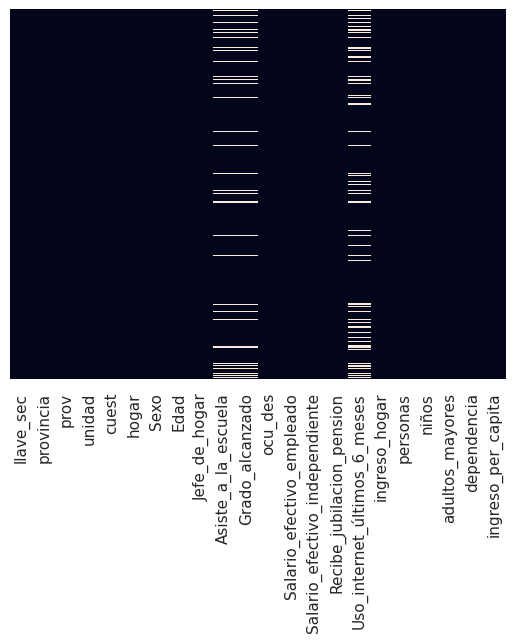

In [196]:
# Distribución de nulos por medio del color blanco
sns.heatmap(df_modelo_final.isnull(), cbar=False, yticklabels = False)

Para visualizar los valores nulos, nos ayudamos con este mapa de calor, marcándolos en blanco

# Recodificación de variables para mejor entendimiento

Se crean diccionarios para transformar los valores numéricos a sus respectivas categorías.

In [197]:
dicc_sexo = {
    1: 'Masculino',
    2: 'Femenino',
}

df_modelo_final.loc[:, 'Sexo'] = df_modelo_final['Sexo'].replace(dicc_sexo).astype(str)

In [198]:
dicc_jefe_h = {
    1: 'Jefe o jefa',
    2: 'Conyugue',
    3: 'Hijo o hija',
    4: 'Otro pariente',
    5: 'Servicio domestico'
}

df_modelo_final.loc[:, 'Jefe_de_hogar'] = df_modelo_final['Jefe_de_hogar'].replace(dicc_jefe_h).astype(str)

In [199]:
dicc_provincia = {
    '01': 'Bocas del Toro',
    '02': 'Coclé',
    '03': 'Colón',
    '04': 'Chiriquí',
    '05': 'Darién',
    '06': 'Herrera',
    '07': 'Los Santos',
    '08': 'Panamá',
    '09': 'Veraguas',
    '10': 'Comarca Guna Yala',
    '11': 'Comarca Emberá-Wounaan',
    '12': 'Comarca Ngäbe-Buglé',
    '13': 'Panamá Oeste'
}

df_modelo_final.loc[:, 'provincia'] = df_modelo_final['provincia'].replace(dicc_provincia)

In [200]:
# Diccionario de recodificación
dicc_nivel_edu = {
    1: 'Ningun grado',
    2: 'Prekínder o prejardín',
    3: 'Kínder o jardín',
    4: 'Enseñanza especial',
    11: 'Primaria',
    12: 'Primaria',
    13: 'Primaria',
    14: 'Primaria',
    15: 'Primaria',
    16: 'Primaria',
    21: 'Vocacional',
    22: 'Vocacional',
    23: 'Vocacional',
    31: 'Primer ciclo premedia',
    32: 'Primer ciclo premedia',
    33: 'Primer ciclo premedia',
    34: 'Segundo ciclo media',
    35: 'Segundo ciclo media',
    36: 'Segundo ciclo media',
    41: 'Superior no universitaria',
    42: 'Superior no universitaria',
    51: 'Superior universitario',
    52: 'Superior universitario',
    53: 'Superior universitario',
    54: 'Superior universitario',
    55: 'Superior universitario',
    56: 'Superior universitario',
    61: 'Especialidad',
    71: 'Maestría',
    72: 'Maestría',
    81: 'Doctorado',
    82: 'Doctorado',
    83: 'Doctorado',
    84: 'Doctorado'
}

# Asegurar formato numérico
df_modelo_final['Grado_alcanzado'] = pd.to_numeric(
    df_modelo_final['Grado_alcanzado'],
    errors='coerce'
)

# Recodificación a texto
df_modelo_final['nivel_edu'] = df_modelo_final['Grado_alcanzado'].map(dicc_nivel_edu)
df_modelo_final['nivel_edu'] = df_modelo_final['nivel_edu'].astype('object')
df_modelo_final['nivel_edu'] = df_modelo_final['nivel_edu'].fillna('Menores de 4 años')

Utilizamos una revisión general después de haber aplicado los diccionarios

In [201]:
df_modelo_final.head(10)

,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita,nivel_edu
0,1.0,Bocas del Toro,01,001,01,1,Masculino,44.0,Jefe o jefa,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Superior universitario
1,1.0,Bocas del Toro,01,001,01,1,Femenino,21.0,Conyugue,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Segundo ciclo media
2,1.0,Bocas del Toro,01,001,01,1,Masculino,4.0,Hijo o hija,2.0,1.0,,0.0,0.0,0.0,NaN,2116.0,3,1,0,0.333333,705.333333,Ningun grado
3,2.0,Bocas del Toro,01,001,02,1,Femenino,22.0,Jefe o jefa,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Segundo ciclo media
4,2.0,Bocas del Toro,01,001,02,1,Masculino,26.0,Conyugue,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Segundo ciclo media
5,2.0,Bocas del Toro,01,001,02,1,Masculino,3.0,Hijo o hija,NaN,NaN,,0.0,0.0,0.0,NaN,1550.0,3,1,0,0.333333,516.666667,Menores de 4 años
6,3.0,Bocas del Toro,01,001,03,1,Femenino,34.0,Jefe o jefa,2.0,36.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Segundo ciclo media
7,3.0,Bocas del Toro,01,001,03,1,Masculino,43.0,Conyugue,2.0,55.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Superior universitario
8,3.0,Bocas del Toro,01,001,03,1,Femenino,16.0,Hijo o hija,1.0,34.0,,0.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Segundo ciclo media
9,3.0,Bocas del Toro,01,001,03,1,Femenino,56.0,Otro pariente,2.0,36.0,Ocupados,526.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Segundo ciclo media


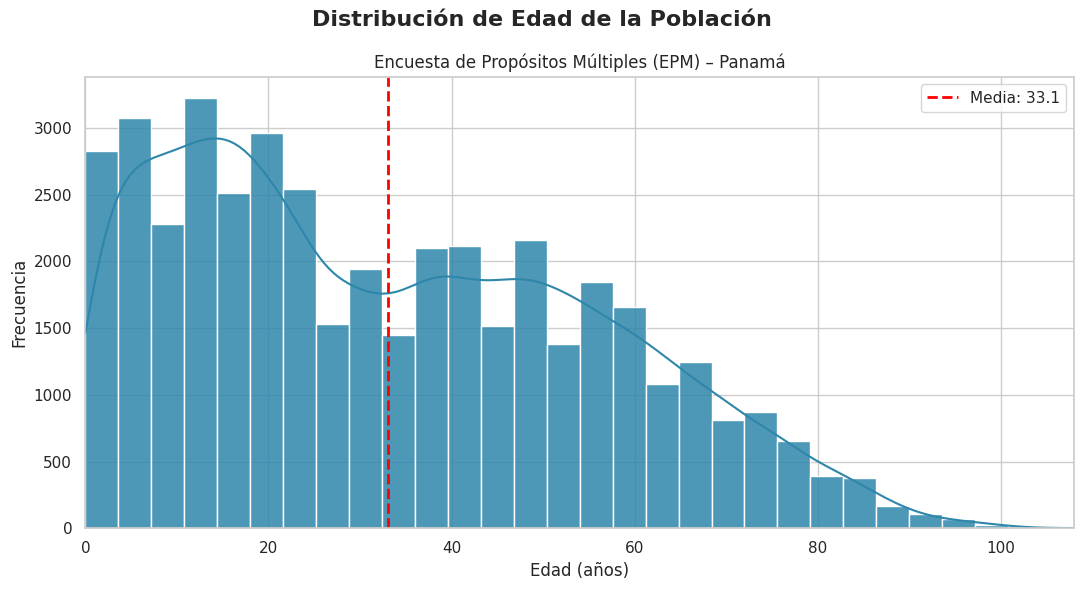

In [203]:
# Distribución de Edad en la encuesta

sns.set_theme(style="whitegrid")

plt.figure(figsize=(11,6))

sns.histplot(
    data=df_modelo_final,
    x='Edad',
    bins=30,
    kde=True,
    color='#2E86AB',
    edgecolor='white',
    alpha=0.85
)

# Línea de media
media_edad = df_modelo_final['Edad'].mean()
plt.axvline(media_edad, color='red', linestyle='--', linewidth=2,
            label=f'Media: {media_edad:.1f}')

plt.suptitle('Distribución de Edad de la Población', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=12)

plt.xlabel('Edad (años)', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xlim(df_modelo_final['Edad'].min(), df_modelo_final['Edad'].max())

plt.legend()
plt.tight_layout()

plt.show()

In [204]:
def clasificar_educacion(x):

    if pd.isna(x):
        return 'Inicial / Sin educación'

    if x in [
        'Ningun grado',
        'Prekínder o prejardín',
        'Kínder o jardín',
        'Enseñanza especial',
        'Menores de 4 años'
    ]:
        return 'Inicial / Sin educación'

    elif x == 'Primaria':
        return 'Primaria'

    elif x in ['Primer ciclo premedia', 'Segundo ciclo media']:
        return 'Media'

    elif x == 'Vocacional':
        return 'Técnico'

    elif x in ['Superior universitario', 'Superior no universitaria']:
        return 'Superior'

    elif x in ['Especialidad', 'Maestría', 'Doctorado']:
        return 'Postgrado'

    else:
        return 'Otros'

In [205]:
df_modelo_final['educacion_grupo'] = df_modelo_final['nivel_edu'].apply(clasificar_educacion)

<Figure size 1100x600 with 0 Axes>

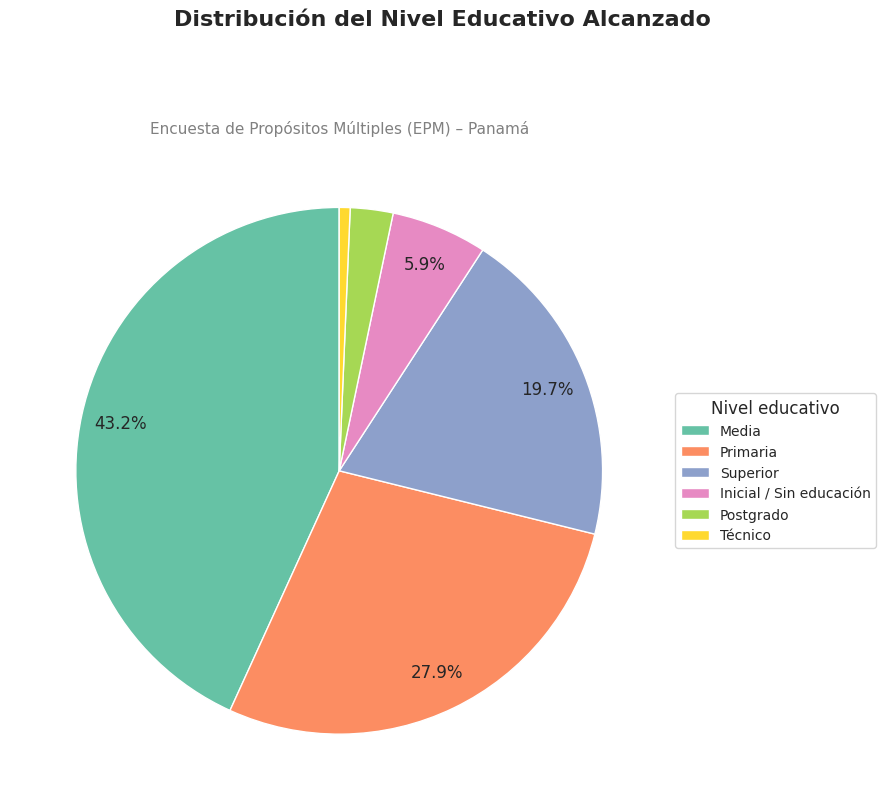

In [206]:
# Gráfica del nivel educativo alcanzado
df_mayores_18 = df_modelo_final[df_modelo_final['Edad'] >= 18].copy()
df_mayores_18['educacion_grupo'] = df_mayores_18['nivel_edu'].apply(clasificar_educacion)

sns.set_theme(style="white")

plt.figure(figsize=(11,6))

# Conteo y orden
conteo = df_mayores_18['educacion_grupo'].value_counts()
orden = conteo.index


plt.figure(figsize=(9,9))

wedges, texts, autotexts = plt.pie(
    conteo,
    labels=None,
    autopct='%1.1f%%',
    startangle=90,
    colors = sns.color_palette("Set2", len(conteo)),
    pctdistance=0.85,
    labeldistance=1.1,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1},
)

for i, (wedge, pct) in enumerate(zip(wedges, conteo / conteo.sum() * 100)):

    if pct < 5:  # umbral para mover afuera

        ang = (wedge.theta2 + wedge.theta1) / 2.
        x = np.cos(np.deg2rad(ang))
        y = np.sin(np.deg2rad(ang))

        autotexts[i].set_visible(False)  # oculta el % interno

plt.legend(
    conteo.index,
    title="Nivel educativo",
    loc="center left",
    bbox_to_anchor=(1, 0.5),
    fontsize=10
)

plt.suptitle('Distribución del Nivel Educativo Alcanzado', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.tight_layout()
plt.show()

# Condición laboral

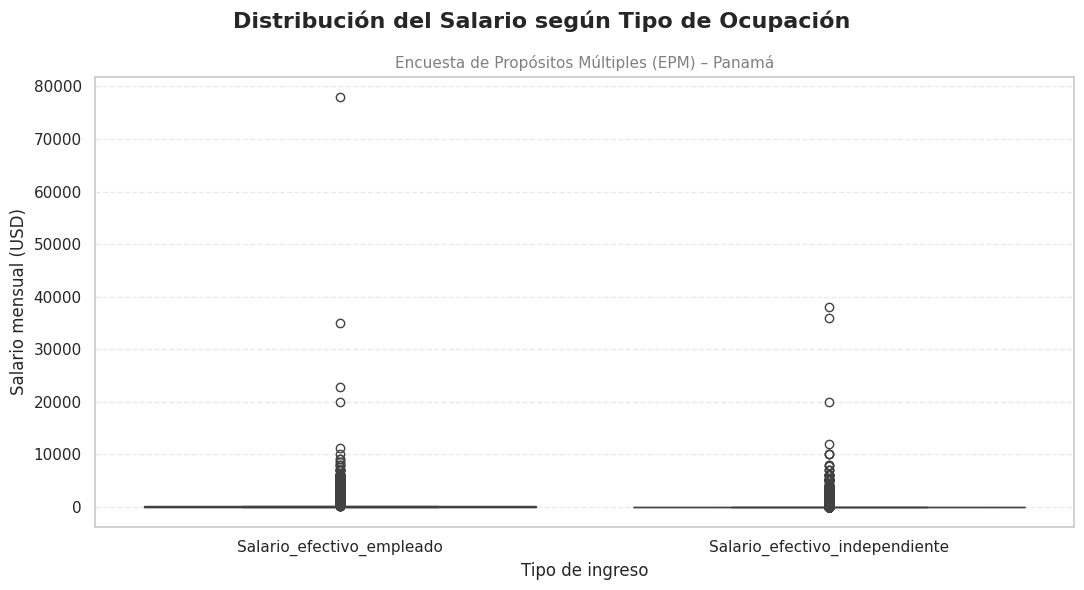

In [207]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(11,6))

sns.boxplot(
    data=df_modelo_final[['Salario_efectivo_empleado',
                          'Salario_efectivo_independiente']],
    palette=['#2E86AB', '#F39C12'],
    showfliers=True
)

plt.suptitle('Distribución del Salario según Tipo de Ocupación', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.xlabel('Tipo de ingreso')
plt.ylabel('Salario mensual (USD)')

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [208]:
df_modelo_final['Grado_alcanzado'] = df_modelo_final['Grado_alcanzado'].fillna('No aplica')
df_modelo_final['Uso_internet_últimos_6_meses'] = df_modelo_final['Uso_internet_últimos_6_meses'].fillna('Sin data')

In [209]:
# Variabla de condición laboral

df_modelo_final['condicion_laboral'] = np.select(
    [
        df_modelo_final['Salario_efectivo_empleado'] > 0,
        df_modelo_final['Salario_efectivo_independiente'] > 0,
        df_modelo_final['Recibe_jubilacion_pension'] == 1,
        (df_modelo_final['ocu_des'] == 'Desocupados') &
        (df_modelo_final['Asiste_a_la_escuela'] == 2),
         df_modelo_final['Asiste_a_la_escuela'] == 1
    ],
    [
        'Empleado',
        'Independiente',
        'Jubilado / pensionado',
        'Desocupado que no estudia',
        'Estudiante'
    ],
    default='Otro'
)


In [210]:
df_pet = df_modelo_final[
    (df_modelo_final['Edad'] >= 18) &
    (df_modelo_final['Edad'] <= 64)
]

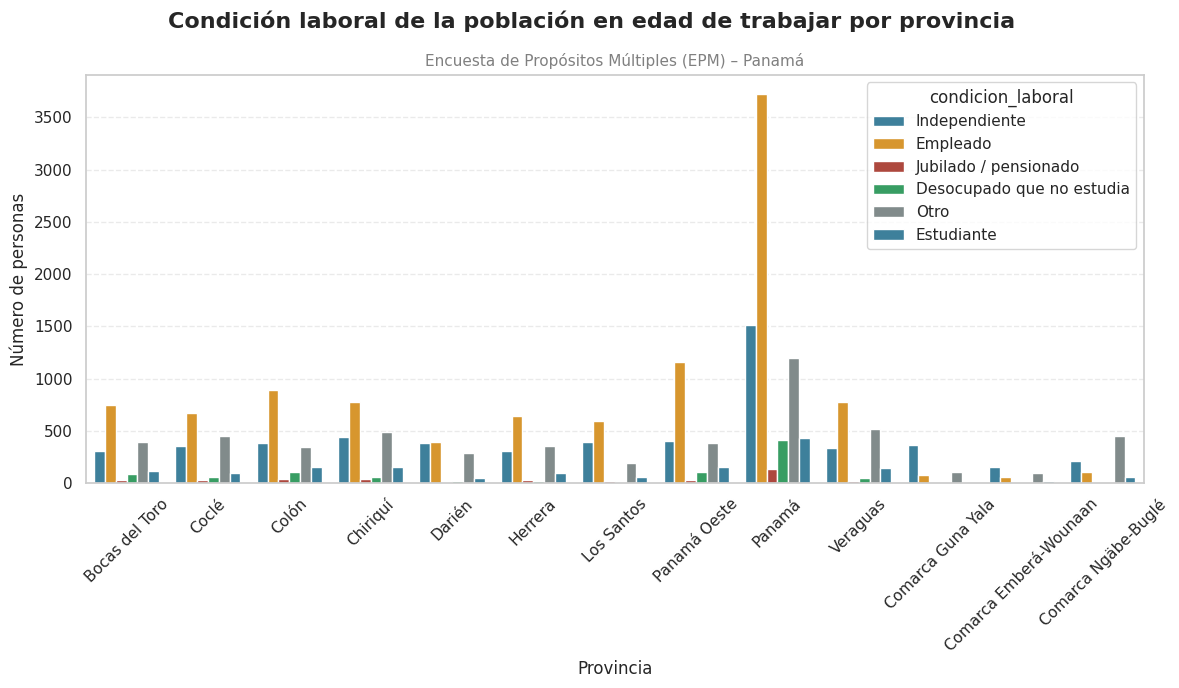

In [211]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(12,7))

sns.countplot(
    data=df_pet,
    x='provincia',
    hue='condicion_laboral',
    palette=['#2E86AB','#F39C12','#C0392B', '#27AE60', '#7F8C8D']
)

plt.suptitle('Condición laboral de la población en edad de trabajar por provincia', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.xlabel('Provincia')
plt.ylabel('Número de personas')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

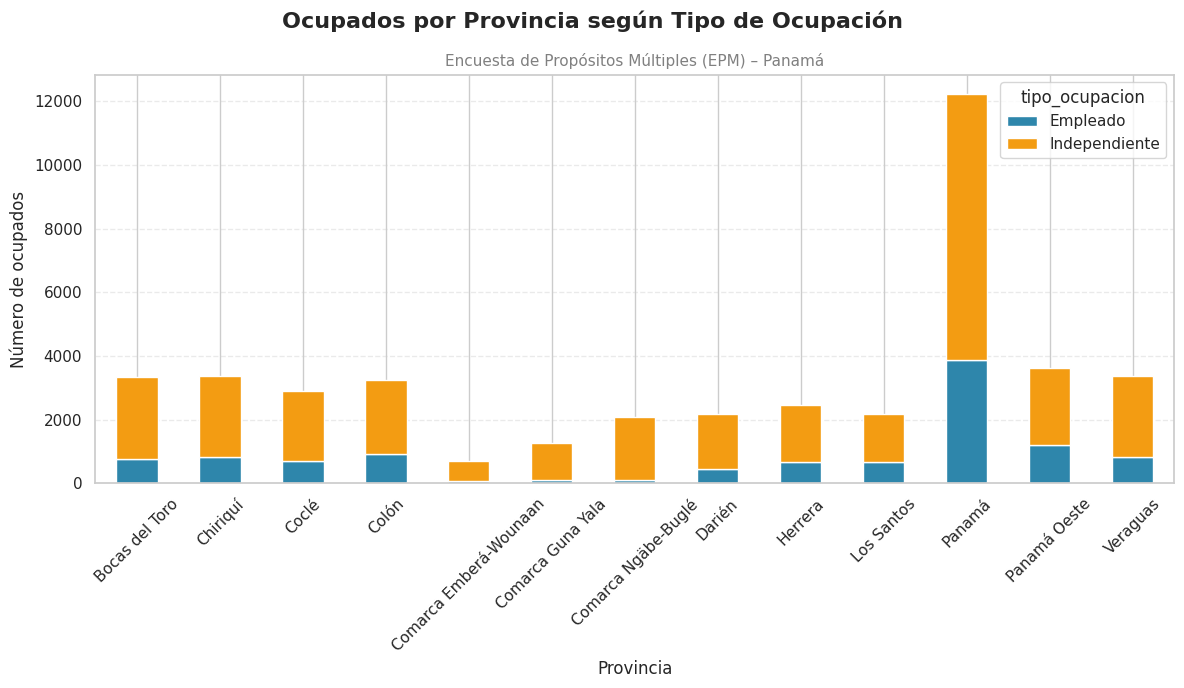

In [212]:
sns.set_theme(style="whitegrid")

# Crear variable tipo de ocupación
df_modelo_final['tipo_ocupacion'] = df_modelo_final.apply(
    lambda x: 'Empleado' if x['Salario_efectivo_empleado'] > 0 else 'Independiente',
    axis=1
)

tabla = pd.crosstab(df_modelo_final['provincia'], df_modelo_final['tipo_ocupacion'])

tabla.plot(
    kind='bar',
    stacked=True,
    figsize=(12,7),
    color=['#2E86AB','#F39C12']
)

plt.suptitle('Ocupados por Provincia según Tipo de Ocupación', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11, color='gray')

plt.xlabel('Provincia')
plt.ylabel('Número de ocupados')

plt.xticks(rotation=45)

plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

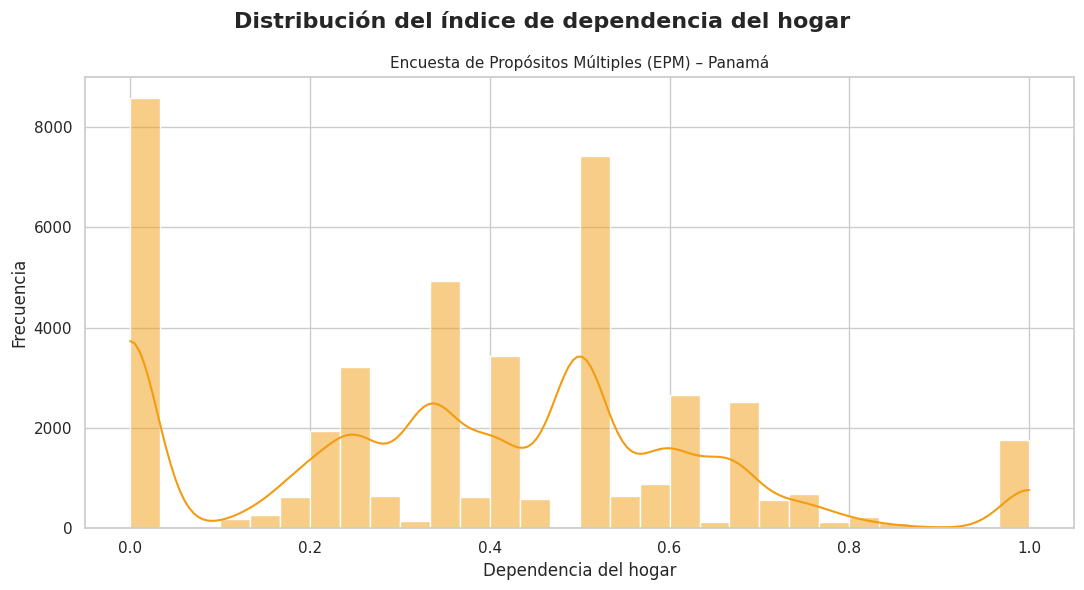

In [213]:
# =========================================
# Distribución dependencia del hogar
# =========================================

plt.figure(figsize=(11,6))

sns.histplot(
    df_modelo_final['dependencia'],
    bins=30,
    kde=True,
    color='#F39C12'
)

plt.suptitle('Distribución del índice de dependencia del hogar', fontsize=16, fontweight='bold')
plt.title('Encuesta de Propósitos Múltiples (EPM) – Panamá', fontsize=11)

plt.xlabel('Dependencia del hogar')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

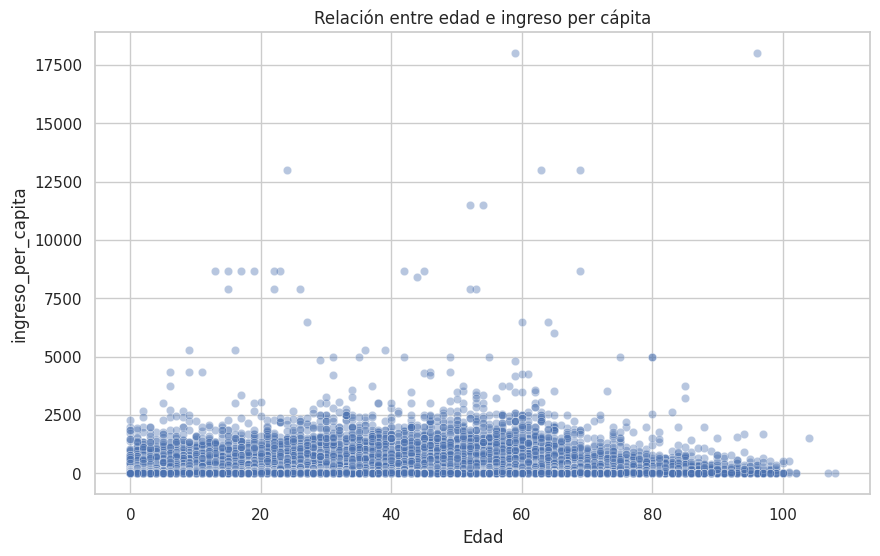

In [214]:
# =========================================
# Edad vs ingreso per capita
# =========================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_modelo_final,
    x='Edad',
    y='ingreso_per_capita',
    alpha=0.4
)

plt.title("Relación entre edad e ingreso per cápita")

plt.xlabel("Edad")
plt.ylabel("ingreso_per_capita")

plt.show()

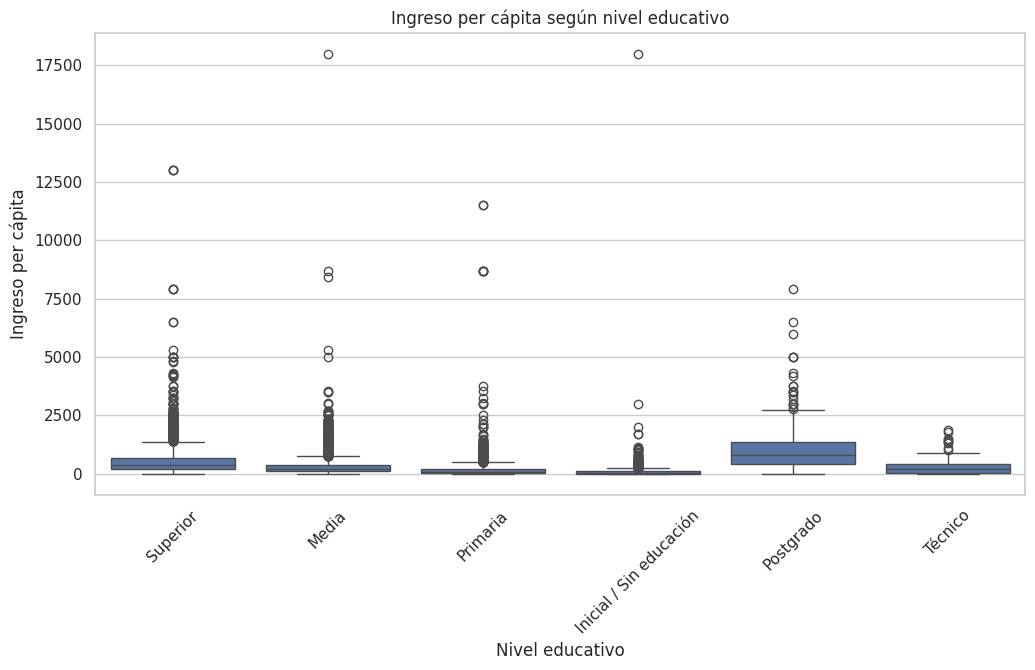

In [215]:
# =========================================
# Educación vs ingreso
# =========================================

plt.figure(figsize=(12,6))

sns.boxplot(
    data=df_mayores_18,
    x='educacion_grupo',
    y='ingreso_per_capita'
)

plt.title("Ingreso per cápita según nivel educativo")

plt.xlabel("Nivel educativo")
plt.ylabel("Ingreso per cápita")

plt.xticks(rotation=45)

plt.show()

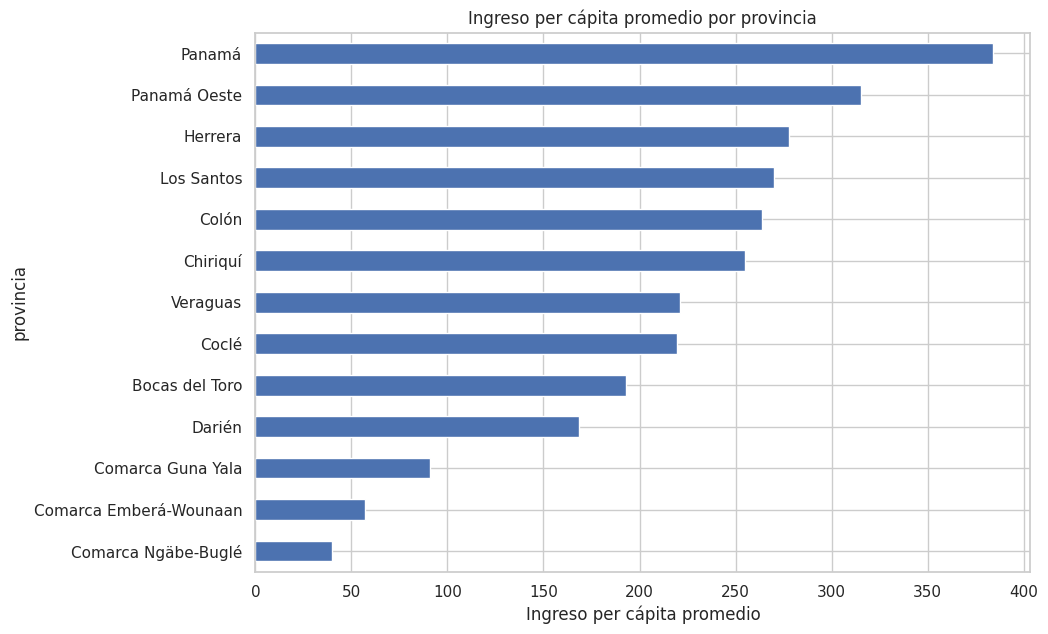

In [216]:
# =========================================
# Ingreso promedio por provincia
# =========================================

ingreso_provincia = df_modelo_final.groupby('provincia')['ingreso_per_capita'].mean().sort_values()

plt.figure(figsize=(10,7))

ingreso_provincia.plot(
    kind='barh'
)

plt.title("Ingreso per cápita promedio por provincia")

plt.xlabel("Ingreso per cápita promedio")

plt.show()

In [217]:
# =========================================
# Población en edad de trabajar
# =========================================

df_pet = df_modelo_final[
    (df_modelo_final['Edad'] >= 18) &
    (df_modelo_final['Edad'] <= 64)
]

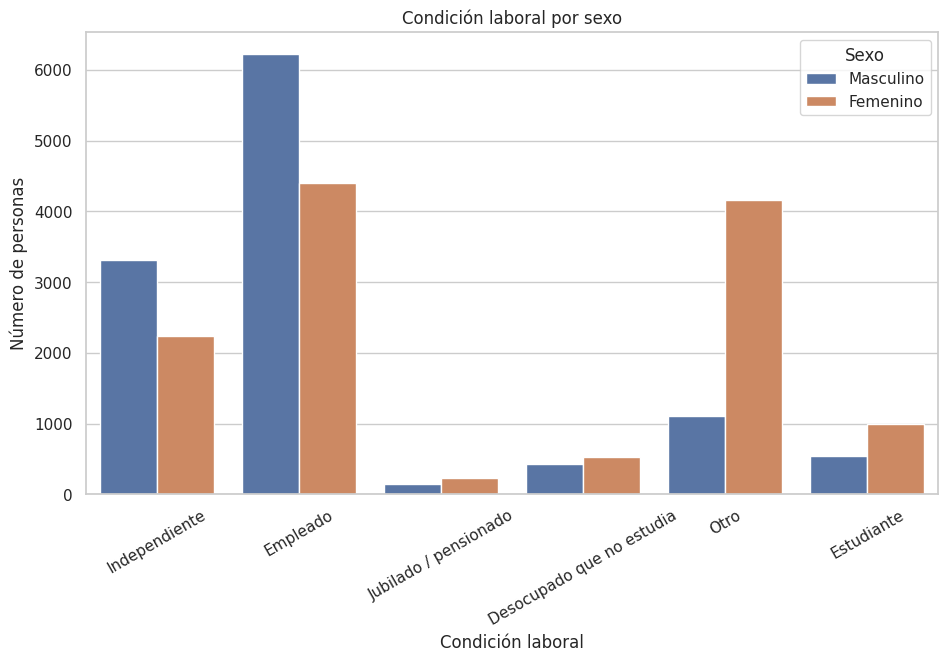

In [218]:
# =========================================
# Condición laboral por sexo
# =========================================

plt.figure(figsize=(11,6))

sns.countplot(
    data=df_pet,
    x='condicion_laboral',
    hue='Sexo'
)

plt.title("Condición laboral por sexo")

plt.xlabel("Condición laboral")
plt.ylabel("Número de personas")

plt.xticks(rotation=30)

plt.show()

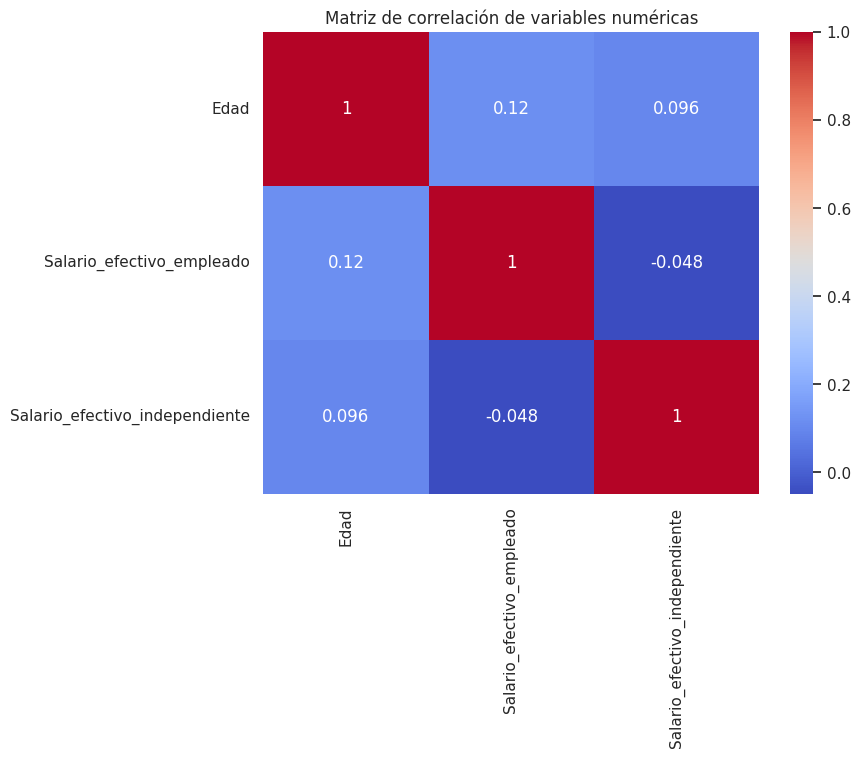

In [219]:
# =========================================
# Correlación entre variables numéricas
# =========================================

variables_numericas = [
    'Edad',
    #'Sexo',
    #'Grado_alcanzado',
    'Salario_efectivo_empleado',
    'Salario_efectivo_independiente'
]

corr = df_modelo_final[variables_numericas].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title("Matriz de correlación de variables numéricas")

plt.show()

# Modelo Mincer

In [220]:
# Función para calcular años de educación basado en el grado de educación alcanzado
def calcular_anios_educacion(codigo):
    try:
        codigo = int(codigo)

        # Sin educación o preescolar
        if codigo <= 10:
            return 0

        # Primaria (11–16 → 1 a 6)
        elif 11 <= codigo <= 16:
            return codigo - 10

        # Vocacional (21–23 → asumimos 7–9)
        elif 21 <= codigo <= 23:
            return codigo - 14  # 7,8,9

        # Premedia (31–33 → 7–9)
        elif 31 <= codigo <= 33:
            return codigo - 24

        # Media (34–36 → 10–12)
        elif 34 <= codigo <= 36:
            return codigo - 24

        # Superior no universitaria (41–42 → 13–14)
        elif 41 <= codigo <= 42:
            return codigo - 28

        # Universidad (51–56 → 13–18)
        elif 51 <= codigo <= 56:
            return codigo - 38

        # Postgrado
        elif codigo == 61:
            return 19
        elif 71 <= codigo <= 72:
            return 20
        elif 81 <= codigo <= 84:
            return 22

        else:
            return 0

    except:
        return 0

In [221]:
# =========================
# 1. Copia de trabajo
# =========================
df_mincer = df_modelo_final.copy()

# =========================
# 2. Filtrar ocupados
# =========================
df_mincer = df_mincer[df_mincer['ocu_des'] == 'Ocupados'].copy()

# =========================
# 3. Años de educación
# =========================
df_mincer['anios_educacion'] = df_mincer['Grado_alcanzado'].apply(
    lambda x: calcular_anios_educacion(x) if pd.notna(x) else np.nan
)

# =========================
# 4. Ingreso laboral total
# =========================
df_mincer['ingreso_laboral'] = (
    df_mincer['Salario_efectivo_empleado'].fillna(0) +
    df_mincer['Salario_efectivo_independiente'].fillna(0)
)

# =========================
# 5. Horas trabajadas
# =========================
df_mincer['Cuantas_horas_trabajó'] = pd.to_numeric(
    df['Cuantas_horas_trabajó'],
    errors='coerce'
)

df_mincer['horas_mensuales'] = df_mincer['Cuantas_horas_trabajó'] * 4.33

# =========================
# 6. Experiencia potencial
# =========================
df_mincer['experiencia'] = np.where(
    df_mincer['Edad'] >= 18,
    df_mincer['Edad'] - np.maximum(df_mincer['anios_educacion'] + 6, 18),
    np.nan
)

df_mincer['experiencia'] = df_mincer['experiencia'].clip(lower=0)
df_mincer['experiencia2'] = df_mincer['experiencia'] ** 2

# =========================
# 7. Salario por hora
# =========================
df_mincer['salario_hora'] = df_mincer['ingreso_laboral'] / df_mincer['horas_mensuales']

# =========================
# 8. Filtrar observaciones válidas
# =========================
df_mincer = df_mincer[
    (df_mincer['Edad'] >= 18) &
    (df_mincer['anios_educacion'].notna()) &
    (df_mincer['ingreso_laboral'] > 0) &
    (df_mincer['Cuantas_horas_trabajó'] > 0) &
    (df_mincer['horas_mensuales'] > 0)
].copy()

# =========================
# 9. Logaritmos
# =========================
df_mincer['ln_ingreso'] = np.log(df_mincer['ingreso_laboral'])
df_mincer['ln_salario_hora'] = np.log(df_mincer['salario_hora'])

# =========================
# 10. Limpieza final
# =========================
df_mincer = df_mincer.replace([np.inf, -np.inf], np.nan)

df_mincer = df_mincer.dropna(subset=[
    'anios_educacion',
    'experiencia',
    'experiencia2',
    'ingreso_laboral',
    'salario_hora',
    'ln_ingreso',
    'ln_salario_hora'
])

# =========================
# 11. Descriptivos
# =========================
display(df_mincer[[
    'Edad',
    'anios_educacion',
    'experiencia',
    'experiencia2',
    'ingreso_laboral',
    'Cuantas_horas_trabajó',
    'horas_mensuales',
    'salario_hora',
    'ln_ingreso',
    'ln_salario_hora'
]].describe())

,Edad,anios_educacion,experiencia,experiencia2,ingreso_laboral,Cuantas_horas_trabajó,horas_mensuales,salario_hora,ln_ingreso,ln_salario_hora
count,17410.000000,17410.000000,17410.000000,17410.000000,17410.000000,17410.000000,17410.000000,17410.000000,17410.000000,17410.000000
mean,42.445491,10.472085,23.238656,757.934463,655.905112,37.156692,160.888474,4.457419,5.930472,0.994031
std,14.574204,4.866551,14.761838,802.142561,1076.339881,14.954736,64.754006,19.453768,1.189205,0.988641
min,18.000000,0.000000,0.000000,0.000000,1.000000,1.000000,4.330000,0.004811,0.000000,-5.336769
25%,30.000000,6.000000,11.000000,121.000000,200.000000,30.000000,129.900000,1.732102,5.298317,0.549335
50%,42.000000,12.000000,22.000000,484.000000,525.000000,40.000000,173.200000,2.949603,6.263398,1.081671
75%,53.000000,13.000000,34.000000,1156.000000,800.000000,48.000000,207.840000,4.618938,6.684612,1.530165
max,96.000000,22.000000,78.000000,6084.000000,77940.000000,98.000000,424.340000,2309.468822,11.263695,7.744773


In [222]:
# Verificación de encabezado
df_mincer.head(10)

,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita,nivel_edu,educacion_grupo,condicion_laboral,tipo_ocupacion,anios_educacion,ingreso_laboral,Cuantas_horas_trabajó,horas_mensuales,experiencia,experiencia2,salario_hora,ln_ingreso,ln_salario_hora
0,1.0,Bocas del Toro,01,001,01,1,Masculino,44.0,Jefe o jefa,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Superior universitario,Superior,Independiente,Independiente,15,1516.0,63.0,272.79,23.0,529.0,5.557388,7.323831,1.715128
1,1.0,Bocas del Toro,01,001,01,1,Femenino,21.0,Conyugue,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Segundo ciclo media,Media,Empleado,Empleado,12,600.0,48.0,207.84,3.0,9.0,2.886836,6.396930,1.060161
3,2.0,Bocas del Toro,01,001,02,1,Femenino,22.0,Jefe o jefa,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Segundo ciclo media,Media,Empleado,Empleado,12,700.0,48.0,207.84,4.0,16.0,3.367975,6.551080,1.214312
4,2.0,Bocas del Toro,01,001,02,1,Masculino,26.0,Conyugue,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Segundo ciclo media,Media,Empleado,Empleado,12,850.0,66.0,285.78,8.0,64.0,2.974316,6.745236,1.090014
6,3.0,Bocas del Toro,01,001,03,1,Femenino,34.0,Jefe o jefa,2.0,36.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Segundo ciclo media,Media,Empleado,Empleado,12,800.0,40.0,173.20,16.0,256.0,4.618938,6.684612,1.530165
7,3.0,Bocas del Toro,01,001,03,1,Masculino,43.0,Conyugue,2.0,55.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Superior universitario,Superior,Empleado,Empleado,17,800.0,48.0,207.84,20.0,400.0,3.849115,6.684612,1.347843
9,3.0,Bocas del Toro,01,001,03,1,Femenino,56.0,Otro pariente,2.0,36.0,Ocupados,526.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Segundo ciclo media,Media,Empleado,Empleado,12,526.0,40.0,173.20,38.0,1444.0,3.036952,6.265301,1.110854
10,4.0,Bocas del Toro,01,001,04,1,Masculino,59.0,Jefe o jefa,2.0,42.0,Ocupados,1000.0,0.0,0.0,1.0,1600.0,3,0,0,0.000000,533.333333,Superior no universitaria,Superior,Empleado,Empleado,14,1000.0,40.0,173.20,39.0,1521.0,5.773672,6.907755,1.753308
12,4.0,Bocas del Toro,01,001,04,1,Femenino,31.0,Hijo o hija,2.0,53.0,Ocupados,600.0,0.0,0.0,1.0,1600.0,3,0,0,0.000000,533.333333,Superior universitario,Superior,Empleado,Empleado,15,600.0,40.0,173.20,10.0,100.0,3.464203,6.396930,1.242483
13,5.0,Bocas del Toro,01,001,05,1,Masculino,37.0,Jefe o jefa,2.0,36.0,Ocupados,0.0,649.0,0.0,1.0,649.0,1,0,0,0.000000,649.000000,Segundo ciclo media,Media,Independiente,Independiente,12,649.0,35.0,151.55,19.0,361.0,4.282415,6.475433,1.454517


## Cálculo del modelo Mincer

In [223]:
# Variables independientes
X = df_mincer[['anios_educacion', 'experiencia', 'experiencia2']]

# Agregar constante
X = sm.add_constant(X)

# Variable dependiente
y = df_mincer['ln_ingreso']

# Estimación OLS
modelo_mincer = sm.OLS(y, X).fit()

# Resultados
print(modelo_mincer.summary())

                            OLS Regression Results                            
Dep. Variable:             ln_ingreso   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.326
Method:                 Least Squares   F-statistic:                     2809.
Date:                Tue, 24 Mar 2026   Prob (F-statistic):               0.00
Time:                        03:43:41   Log-Likelihood:                -24283.
No. Observations:               17410   AIC:                         4.857e+04
Df Residuals:                   17406   BIC:                         4.860e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.1686      0.027    1

# Modelo Heckman

In [224]:
# Preparación del dataset

In [225]:
df_heckman = df_modelo[columnas_finales].copy()

In [226]:
# Asegurar índice alineado
df_heckman = df_heckman.copy()
df_heckman.index = df_modelo.index

In [227]:
# ==========================================
# 2. Variables base para Heckman
# ==========================================

df_heckman['area_geografica'] = df['Área_geográfica']

df_heckman['prov'] = pd.to_numeric(df_heckman['prov'], errors='coerce').astype('Int64')

# Variables traídas desde df_mincer
for col in ['ln_salario_hora', 'anios_educacion', 'experiencia', 'experiencia2']:
    if col in df_mincer.columns:
        df_heckman[col] = df_mincer[col]
    else:
        print(f'Falta en df_mincer: {col}')

In [228]:
# Seguridad social
df_heckman['Seguro_Social'] = df_modelo['Seguro_Social']
df_heckman['tiene_CSS'] = np.where(df_heckman['Seguro_Social'] == 6, 0, 1)


In [229]:
# Grado alcanzado

def clasificar_educacion_desde_codigo(x):
    if pd.isna(x):
        return 'Inicial / Sin educación'

    try:
        x = int(x)
    except:
        return 'Otros'

    if x in [1, 2, 3, 4]:
        return 'Inicial / Sin educación'
    elif x in [11, 12, 13, 14, 15, 16]:
        return 'Primaria'
    elif x in [31, 32, 33, 34, 35, 36]:
        return 'Media'
    elif x in [21, 22, 23]:
        return 'Técnico'
    elif x in [41, 42, 51, 52, 53, 54, 55, 56]:
        return 'Superior'
    elif x in [61, 71, 72, 81, 82, 83, 84]:
        return 'Postgrado'
    else:
        return 'Otros'

# Asegurar formato numérico
df_heckman['Grado_alcanzado'] = pd.to_numeric(
    df_heckman['Grado_alcanzado'],
    errors='coerce'
)

# Crear variable reclasificada
df_heckman['educacion_grupo'] = df_heckman['Grado_alcanzado'].apply(clasificar_educacion_desde_codigo)


# Unir al dataframe
df_heckman = pd.concat([df_heckman, dummies_educacion], axis=1)


In [230]:
##Variables de seguridad social
df['seguridad_social'] = (
    df['p72a'].fillna(0) +
    df['p72b'].fillna(0) +
    df['p72g1'].fillna(0) +
    df['p72g2'].fillna(0) +
    df['p72g3'].fillna(0) +
    df['p72g4'].fillna(0) +
    df['p72g5'].fillna(0) +
    df['p72g6'].fillna(0)
)

df_heckman['seguridad_social'] = df['seguridad_social']


In [231]:
## Cómo construir variable: Ingreso no laboral
df['ingreso_no_laboral'] = (
    df['p72c1'].fillna(0) +
    df['p72c2'].fillna(0) +
    df['p72c3'].fillna(0) +
    df['p72c4'].fillna(0) +
    df['p72c5'].fillna(0) +
    df['p72c7'].fillna(0) +
    df['p72c8'].fillna(0) +
    df['p72f1'].fillna(0) +
    df['p72f2'].fillna(0) +
    df['p72f3'].fillna(0) +
    df['p72f4'].fillna(0)
)

df_heckman['ingreso_no_laboral'] = df['ingreso_no_laboral']


In [232]:
# Variable Tipo de contrato
df_heckman['tipo_contrato'] = pd.to_numeric(df['Tipo_de_contrato'], errors='coerce').fillna(0)

df_heckman['tipo_contrato_eco'] = np.select(
    [
        df_heckman['tipo_contrato'].isin([1, 4]),
        df_heckman['tipo_contrato'].isin([2, 3]),
        df_heckman['tipo_contrato'] == 5
    ],
    [
        'Formal',
        'Temporal',
        'Informal'
    ],
    default='No especificado'
)

In [233]:
# Variable tamaño de la empresa

# Limpiar la columna original (sin modificar df)
p29_clean = pd.to_numeric(df_modelo['p29'], errors='coerce')

df_heckman['tamano_empresa'] = p29_clean.map({
    1: 'Microempresa',
    2: 'Microempresa',
    3: 'Pequeña',
    4: 'Pequeña',
    5: 'Mediana_Grande'
}).fillna('Sin respuesta')

df_heckman['tamano_empresa_rec'] = p29_clean.map({
    1: 1,
    2: 1,
    3: 2,
    4: 2,
    5: 3
}).fillna(0).astype(int)

In [234]:
# Reclasificación en 7 sectores
# 1. Crear sector_eco_7 dentro de df_modelo

col_rama = 'Actividad_económica'
df_modelo[col_rama] = pd.to_numeric(df_modelo[col_rama], errors='coerce')

def recodificar_sector_eco_7(x):
    if pd.isna(x):
        return np.nan
    x = int(x)

    if x in [1, 2]:
        return 'Primario'
    elif x in [3, 4, 5]:
        return 'Manufactura y utilities'
    elif x == 6:
        return 'Construcción'
    elif x in [7, 8, 9]:
        return 'Comercio, transporte y turismo'
    elif x in [10, 11, 12, 13, 14]:
        return 'Servicios empresariales y financieros'
    elif x in [15, 16, 17]:
        return 'Sector público y social'
    elif x in [18, 19, 20, 21]:
        return 'Otros servicios y hogares'
    else:
        return np.nan

df_heckman['sector_eco_7'] = df_modelo[col_rama].apply(recodificar_sector_eco_7)

In [235]:
# Variable provincia

# =========================
# Recodificar provincia
# =========================
dicc_provincia = {
    '01': 'Bocas del Toro',
    '02': 'Coclé',
    '03': 'Colón',
    '04': 'Chiriquí',
    '05': 'Darién',
    '06': 'Herrera',
    '07': 'Los Santos',
    '08': 'Panamá',
    '09': 'Veraguas',
    '10': 'Comarca Guna Yala',
    '11': 'Comarca Emberá-Wounaan',
    '12': 'Comarca Ngäbe-Buglé',
    '13': 'Panamá Oeste'
}

# Asegurar tipo string con cero a la izquierda
df_heckman['provincia'] = df_heckman['provincia'].astype(str).str.zfill(2)

# Reemplazar códigos por etiquetas
df_heckman['provincia'] = df_heckman['provincia'].replace(dicc_provincia)

In [236]:
## Variable jornada laboral

col_horas = 'Cuantas_horas_trabajó'
df_heckman['horas_semana'] = pd.to_numeric(df[col_horas], errors='coerce')
df_heckman['horas_mensuales'] = df_heckman['horas_semana'] * 4.33

df_heckman['jornada_dummy'] = np.where(
    df_heckman['horas_semana'] >= 40, 1,
    np.where(df_heckman['horas_semana'].notna(), 0, np.nan)
)

df_heckman['tipo_jornada'] = pd.NA
df_heckman.loc[df_heckman['horas_semana'] >= 40, 'tipo_jornada'] = 'Jornada completa'
df_heckman.loc[
    (df_heckman['horas_semana'] < 40) & (df_heckman['horas_semana'].notna()),
    'tipo_jornada'
] = 'Jornada parcial'

def clasificar_jornada(h):
    if pd.isna(h):
        return np.nan
    elif h < 15:
        return 'Muy reducida'
    elif h < 40:
        return 'Parcial'
    elif h <= 48:
        return 'Completa estándar'
    else:
        return 'Extendida'

df_heckman['jornada_categoria'] = df_heckman['horas_semana'].apply(clasificar_jornada)

In [237]:
# Variable Estado_civil y jefe de hogar

# Traer la variable correctamente desde df
df_heckman['Estado_civil'] = df['Estado_civil']

#Crear variable numérica reclasificada
df_heckman['estado_civil_rec'] = np.select(
    [
        df_heckman['Estado_civil'].isin([1, 4]),
        df_heckman['Estado_civil'].isin([2, 3, 6]),
        df_heckman['Estado_civil'] == 7,
        df_heckman['Estado_civil'] == 5,
        df_heckman['Estado_civil'] == 8
    ],
    [1, 2, 3, 4, 5],
    default=np.nan
)

df_heckman['jefe_hogar_rec'] = np.select(
    [
        df_heckman['Jefe_de_hogar'] == 1,
        df_heckman['Jefe_de_hogar'] == 2,
        df_heckman['Jefe_de_hogar'] == 3,
        df_heckman['Jefe_de_hogar'] == 4,
        df_heckman['Jefe_de_hogar'].isin([5, 6])
    ],
    [1, 2, 3, 4, 5],
    default=np.nan
)

In [238]:
# ==============================
# VARIABLE: ANTIGÜEDAD LABORAL
# ==============================

df['antiguedad_meses'] = pd.to_numeric(df['p34'], errors='coerce')
df['antiguedad_anios'] = df['antiguedad_meses'] / 12
df_heckman['antiguedad_anios'] = df['antiguedad_anios']

In [239]:
df_heckman.head(10)

,llave_sec,provincia,prov,unidad,cuest,hogar,Sexo,Edad,Jefe_de_hogar,Asiste_a_la_escuela,Grado_alcanzado,ocu_des,Salario_efectivo_empleado,Salario_efectivo_independiente,Recibe_jubilacion_pension,Uso_internet_últimos_6_meses,ingreso_hogar,personas,niños,adultos_mayores,dependencia,ingreso_per_capita,area_geografica,ln_salario_hora,anios_educacion,experiencia,experiencia2,Seguro_Social,tiene_CSS,educacion_grupo,edu_Media,edu_Postgrado,edu_Primaria,edu_Superior,edu_Técnico,seguridad_social,ingreso_no_laboral,tipo_contrato,tipo_contrato_eco,tamano_empresa,tamano_empresa_rec,sector_eco_7,horas_semana,horas_mensuales,jornada_dummy,tipo_jornada,jornada_categoria,Estado_civil,estado_civil_rec,jefe_hogar_rec,antiguedad_anios
0,1.0,Bocas del Toro,1,001,01,1,1.0,44.0,1.0,2.0,53.0,Ocupados,0.0,1516.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Urbana,1.715128,15.0,23.0,529.0,1.0,1,Superior,0,0,0,1,0,0.0,0.0,0.0,No especificado,Microempresa,1,"Comercio, transporte y turismo",63.0,272.79,1.0,Jornada completa,Extendida,1.0,1.0,1.0,17.250000
1,1.0,Bocas del Toro,1,001,01,1,2.0,21.0,2.0,2.0,36.0,Ocupados,600.0,0.0,0.0,2.0,2116.0,3,1,0,0.333333,705.333333,Urbana,1.060161,12.0,3.0,9.0,2.0,1,Media,1,0,0,0,0,0.0,0.0,3.0,Temporal,Pequeña,2,"Comercio, transporte y turismo",48.0,207.84,1.0,Jornada completa,Completa estándar,1.0,1.0,2.0,16.833333
2,1.0,Bocas del Toro,1,001,01,1,1.0,4.0,3.0,2.0,1.0,,0.0,0.0,0.0,NaN,2116.0,3,1,0,0.333333,705.333333,Urbana,NaN,NaN,NaN,NaN,2.0,1,Inicial / Sin educación,0,0,0,0,0,0.0,0.0,0.0,No especificado,Sin respuesta,0,NaN,NaN,NaN,NaN,<NA>,NaN,8.0,5.0,3.0,NaN
3,2.0,Bocas del Toro,1,001,02,1,2.0,22.0,1.0,2.0,36.0,Ocupados,700.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Urbana,1.214312,12.0,4.0,16.0,1.0,1,Media,1,0,0,0,0,0.0,0.0,4.0,Formal,Pequeña,2,"Comercio, transporte y turismo",48.0,207.84,1.0,Jornada completa,Completa estándar,1.0,1.0,1.0,9.083333
4,2.0,Bocas del Toro,1,001,02,1,1.0,26.0,2.0,2.0,36.0,Ocupados,850.0,0.0,0.0,1.0,1550.0,3,1,0,0.333333,516.666667,Urbana,1.090014,12.0,8.0,64.0,1.0,1,Media,1,0,0,0,0,0.0,0.0,4.0,Formal,Mediana_Grande,3,"Comercio, transporte y turismo",66.0,285.78,1.0,Jornada completa,Extendida,1.0,1.0,2.0,8.583333
5,2.0,Bocas del Toro,1,001,02,1,1.0,3.0,3.0,NaN,NaN,,0.0,0.0,0.0,NaN,1550.0,3,1,0,0.333333,516.666667,Urbana,NaN,NaN,NaN,NaN,6.0,0,Inicial / Sin educación,0,0,0,0,0,0.0,20.0,0.0,No especificado,Sin respuesta,0,NaN,NaN,NaN,NaN,<NA>,NaN,8.0,5.0,3.0,NaN
6,3.0,Bocas del Toro,1,001,03,1,2.0,34.0,1.0,2.0,36.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Urbana,1.530165,12.0,16.0,256.0,1.0,1,Media,1,0,0,0,0,0.0,0.0,1.0,Formal,Mediana_Grande,3,Sector público y social,40.0,173.20,1.0,Jornada completa,Completa estándar,4.0,1.0,1.0,17.083333
7,3.0,Bocas del Toro,1,001,03,1,1.0,43.0,2.0,2.0,55.0,Ocupados,800.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Urbana,1.347843,17.0,20.0,400.0,1.0,1,Superior,0,0,0,1,0,0.0,0.0,1.0,Formal,Mediana_Grande,3,Sector público y social,48.0,207.84,1.0,Jornada completa,Completa estándar,4.0,1.0,2.0,18.333333
8,3.0,Bocas del Toro,1,001,03,1,2.0,16.0,3.0,1.0,34.0,,0.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Urbana,NaN,NaN,NaN,NaN,2.0,1,Media,1,0,0,0,0,0.0,50.0,0.0,No especificado,Sin respuesta,0,NaN,NaN,NaN,NaN,<NA>,NaN,7.0,3.0,3.0,NaN
9,3.0,Bocas del Toro,1,001,03,1,2.0,56.0,4.0,2.0,36.0,Ocupados,526.0,0.0,0.0,1.0,2126.0,4,0,0,0.000000,531.500000,Urbana,1.110854,12.0,38.0,1444.0,1.0,1,Media,1,0,0,0,0,0.0,0.0,4.0,Formal,Microempresa,1,Otros servicios y hogares,40.0,173.20,1.0,Jornada completa,Completa estándar,3.0,2.0,4.0,18.416667


## Cálculo del modelo Heckman

In [240]:
# Importación de librería
from scipy.stats import norm

In [241]:
# Variable de selección
df_heckman['participa'] = np.where(
    df_heckman['ocu_des'] == 'Ocupados',
    1,
    0
)

In [242]:
# Edad al cuadrado
df_heckman['Edad2'] = df_heckman['Edad'] ** 2
df_heckman[''] = df_heckman['Edad'] ** 2

In [243]:
# Variables de selección
vars_seleccion = [
    'Edad',
    'Edad2',
    'Sexo',
    'Asiste_a_la_escuela',
    'Recibe_jubilacion_pension',
    'niños',
    'adultos_mayores',
    'ingreso_hogar',
    'estado_civil_rec',
    'jefe_hogar_rec',
    'ingreso_no_laboral',
    'prov',
    'participa'
]

df_sel = df_heckman[vars_seleccion].dropna().copy()

### Probit de participación

In [244]:
# Probit de participación
X_sel = df_sel[['Edad', 'Edad2', 'Sexo', 'Asiste_a_la_escuela',
                'Recibe_jubilacion_pension', 'niños',
                'adultos_mayores', 'ingreso_hogar',
                'estado_civil_rec', 'jefe_hogar_rec',
                'ingreso_no_laboral',
              ]]

X_sel = sm.add_constant(X_sel)
y_sel = df_sel['participa']

probit_model = sm.Probit(y_sel, X_sel)
probit_res = probit_model.fit()
print(probit_res.summary())

Optimization terminated successfully.
         Current function value: 0.416040
         Iterations 6
                          Probit Regression Results                           
Dep. Variable:              participa   No. Observations:                40096
Model:                         Probit   Df Residuals:                    40084
Method:                           MLE   Df Model:                           11
Date:                Tue, 24 Mar 2026   Pseudo R-squ.:                  0.3998
Time:                        03:43:43   Log-Likelihood:                -16682.
converged:                       True   LL-Null:                       -27792.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -1.7353      0.080    -21.721      0.000      -1.

In [245]:
# Calcular razón de Mills inversa (para saber si el modelo se está ajustando o nó)
df_sel['xb'] = probit_res.predict(X_sel, linear=True)
df_sel['IMR'] = norm.pdf(df_sel['xb']) / norm.cdf(df_sel['xb'])
df_sel['IMR'] = df_sel['IMR'].replace([np.inf, -np.inf], np.nan)

df_heckman = df_heckman.merge(
    df_sel[['IMR']],
    left_index=True,
    right_index=True,
    how='left'
)

### Ecuación salarial

In [246]:
# Segunda etapa: ecuación salarial

vars_salario = [
    'ln_salario_hora',
    'anios_educacion',
    'experiencia',
    'experiencia2',
    'Sexo',
    'antiguedad_anios',
    'IMR',
    'tiene_CSS',
    'horas_mensuales',
    'educacion_grupo',
    'tipo_contrato_eco',
    'tamano_empresa',
    'area_geografica',
    'jornada_categoria',
    'estado_civil_rec',
    'sector_eco_7',
    'provincia',
    'participa'
]

"""
# Verificar qué columnas existen realmente
faltantes = [col for col in vars_salario if col not in df_heckman.columns]
print("Columnas faltantes:", faltantes)
"""

# Seleccionar solo si existen
vars_salario_ok = [col for col in vars_salario if col in df_heckman.columns]

df_wage = df_heckman[vars_salario_ok].copy()

# Filtrar solo ocupados/participantes
df_wage = df_wage[df_wage['participa'] == 1].copy()

# Crear dummies de variables categóricas
cols_dummies = [c for c in ['educacion_grupo',
                            'estado_civil_rec',
                            'tipo_contrato_eco',
                            'tamano_empresa',
                            'jornada_categoria',
                            'area_geografica',
                            'sector_eco_7',
                            'provincia'
                            ] if c in df_wage.columns]

if cols_dummies:
    df_wage = pd.get_dummies(
        df_wage,
        columns=cols_dummies,
        drop_first=True,
        dtype=int
    )

# Convertir Sexo a numérico si está como texto
if 'Sexo' in df_wage.columns:
    if df_wage['Sexo'].dtype == 'object':
        df_wage['Sexo'] = df_wage['Sexo'].replace({
            'Hombre': 1,
            'Mujer': 0,
            'Masculino': 1,
            'Femenino': 0
        })

# Convertir booleanos a enteros
for col in df_wage.columns:
    if df_wage[col].dtype == 'bool':
        df_wage[col] = df_wage[col].astype(int)

# Forzar numérico
for col in df_wage.columns:
    df_wage[col] = pd.to_numeric(df_wage[col], errors='coerce')

# Eliminar nulos
df_wage = df_wage.dropna().copy()

# Definir X e y
X_wage = df_wage.drop(columns=['ln_salario_hora', 'participa'], errors='ignore')
X_wage = sm.add_constant(X_wage)

y_wage = df_wage['ln_salario_hora'].astype(float)
X_wage = X_wage.astype(float)

print(X_wage.dtypes)
print(y_wage.dtype)

wage_model = sm.OLS(y_wage, X_wage).fit()
print(wage_model.summary())

const                                                 float64
anios_educacion                                       float64
experiencia                                           float64
experiencia2                                          float64
Sexo                                                  float64
antiguedad_anios                                      float64
IMR                                                   float64
tiene_CSS                                             float64
horas_mensuales                                       float64
educacion_grupo_Media                                 float64
educacion_grupo_Postgrado                             float64
educacion_grupo_Primaria                              float64
educacion_grupo_Superior                              float64
educacion_grupo_Técnico                               float64
estado_civil_rec_2.0                                  float64
estado_civil_rec_3.0                                  float64
estado_c

# Logistic Regression, Random Forest y Gradient Boosting

Columnas faltantes: []
Numéricas: ['Edad', 'Edad2', 'anios_educacion', 'niños', 'adultos_mayores', 'ingreso_hogar', 'ingreso_no_laboral']
Categóricas: ['Sexo', 'Asiste_a_la_escuela', 'estado_civil_rec', 'jefe_hogar_rec', 'provincia', 'Área_geográfica']


,Accuracy,Precision,Recall,F1,ROC_AUC
Gradient Boosting,0.943053,0.947439,0.994678,0.970484,0.926379
Random Forest,0.943053,0.945300,0.997199,0.970556,0.914917
Logistic Regression,0.941471,0.941456,1.000000,0.969845,0.773733



===== Logistic Regression =====
              precision    recall  f1-score   support

         0.0       1.00      0.00      0.01       223
         1.0       0.94      1.00      0.97      3570

    accuracy                           0.94      3793
   macro avg       0.97      0.50      0.49      3793
weighted avg       0.94      0.94      0.91      3793


===== Random Forest =====
              precision    recall  f1-score   support

         0.0       0.63      0.08      0.14       223
         1.0       0.95      1.00      0.97      3570

    accuracy                           0.94      3793
   macro avg       0.79      0.54      0.55      3793
weighted avg       0.93      0.94      0.92      3793


===== Gradient Boosting =====
              precision    recall  f1-score   support

         0.0       0.58      0.12      0.19       223
         1.0       0.95      0.99      0.97      3570

    accuracy                           0.94      3793
   macro avg       0.76      0.56    

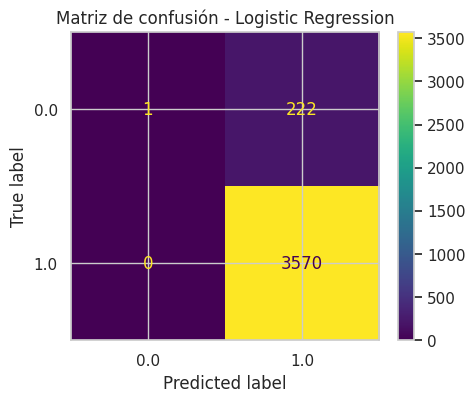

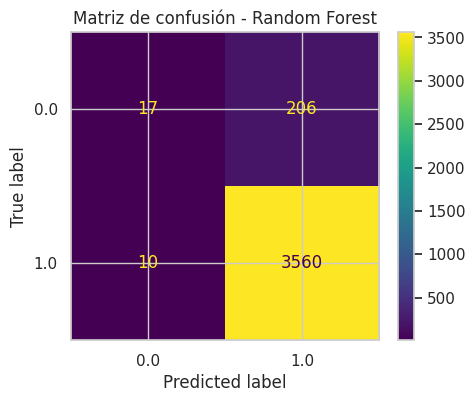

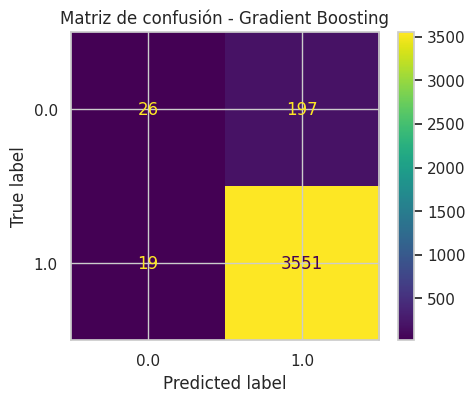

<Figure size 700x500 with 0 Axes>

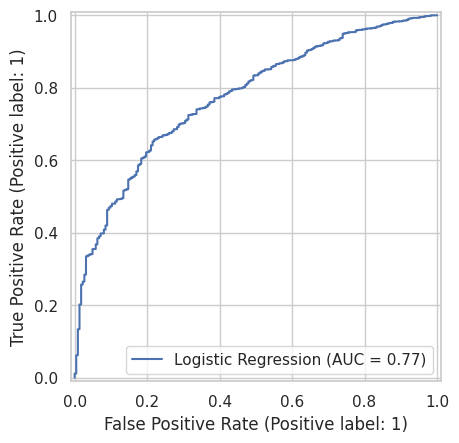

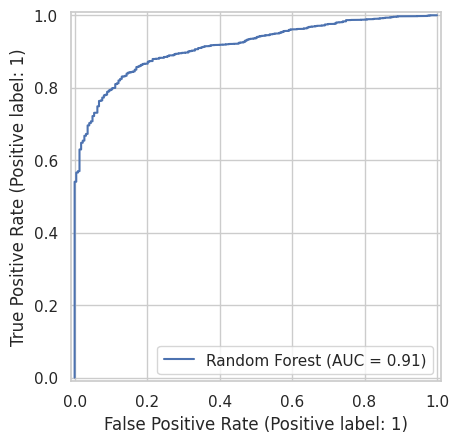

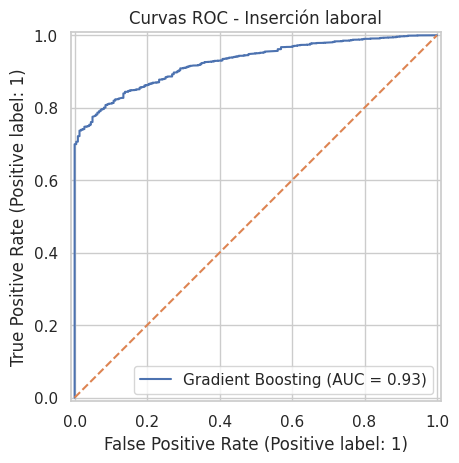

,variable,importancia
5,num__ingreso_hogar,0.232253
2,num__anios_educacion,0.224567
1,num__Edad2,0.124661
0,num__Edad,0.120469
3,num__niños,0.064040
15,cat__Área_geográfica_Urbana,0.061049
6,num__ingreso_no_laboral,0.053028
12,cat__jefe_hogar_rec_3.0,0.033607
9,cat__estado_civil_rec_3.0,0.019722
4,num__adultos_mayores,0.016198


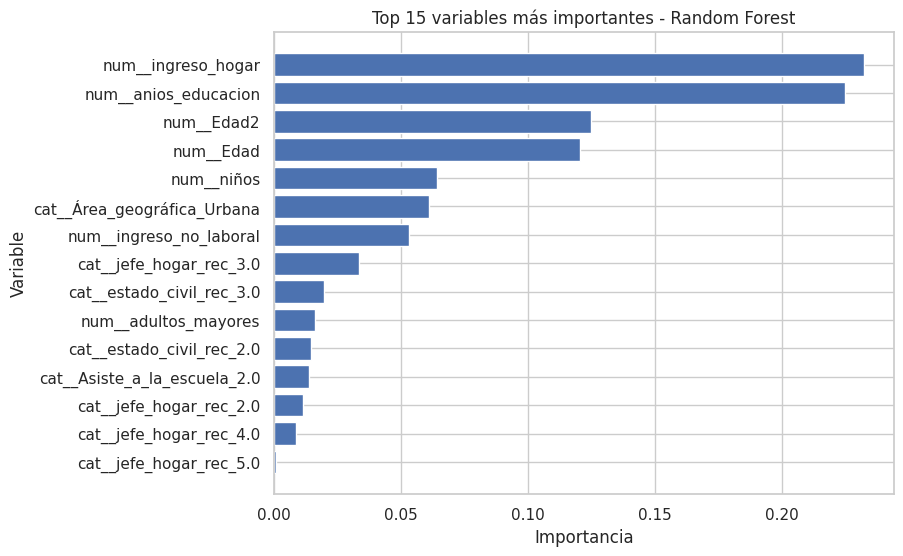

In [286]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# =========================
# 1. Copia base
# =========================
df_ml = df_modelo_final.copy()

# Variable objetivo: inserción laboral
df_ml['insercion_laboral'] = df_ml['ocu_des'].map({
    'Ocupados': 1,
    'Desocupados': 0,
    'Inactivos': 0
})

# Filtrar población en edad laboral
df_ml = df_ml[(df_ml['Edad'] >= 18) & (df_ml['Edad'] <= 65)].copy()

# Variable cuadrática de edad
df_ml['Edad2'] = df_ml['Edad'] ** 2

# =========================
# 2. Traer variables desde otros dataframes
# =========================
cols_mincer = [
    'anios_educacion',
    'experiencia',
    'experiencia2'
]

for col in cols_mincer:
    if col in df_mincer.columns:
        df_ml[col] = df_mincer[col]

cols_heckman = [
    'estado_civil_rec',
    'jefe_hogar_rec',
    'ingreso_no_laboral'
]

for col in cols_heckman:
    if col in df_heckman.columns:
        df_ml[col] = df_heckman[col]

# Área geográfica desde df original
if 'Área_geográfica' in df.columns:
    df_ml['Área_geográfica'] = df['Área_geográfica']
elif 'Area_geografica' in df.columns:
    df_ml['Área_geográfica'] = df['Area_geografica']

# =========================
# 3. Selección de variables
# =========================
features = [
    'Edad',
    'Edad2',
    'Sexo',
    'anios_educacion',
    'Asiste_a_la_escuela',
    'estado_civil_rec',
    'jefe_hogar_rec',
    'niños',
    'adultos_mayores',
    'ingreso_hogar',
    'ingreso_no_laboral',
    'provincia',
    'Área_geográfica'
]

target = 'insercion_laboral'

# Verificar columnas existentes
faltantes = [c for c in features + [target] if c not in df_ml.columns]
print("Columnas faltantes:", faltantes)

features_validas = [c for c in features if c in df_ml.columns]

df_model = df_ml[features_validas + [target]].copy()

# =========================
# 4. Convertir numéricas
# =========================
cols_a_numericas = [
    'Edad',
    'Edad2',
    'Sexo',
    'anios_educacion',
    'Asiste_a_la_escuela',
    'estado_civil_rec',
    'jefe_hogar_rec',
    'niños',
    'adultos_mayores',
    'ingreso_hogar',
    'ingreso_no_laboral',
    'provincia'
]

for col in cols_a_numericas:
    if col in df_model.columns:
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

# El target también
df_model[target] = pd.to_numeric(df_model[target], errors='coerce')

# =========================
# 5. Definir columnas numéricas y categóricas
# =========================
num_cols = [
    c for c in [
        'Edad',
        'Edad2',
        'anios_educacion',
        'niños',
        'adultos_mayores',
        'ingreso_hogar',
        'ingreso_no_laboral'
    ] if c in df_model.columns
]

cat_cols = [
    c for c in [
        'Sexo',
        'Asiste_a_la_escuela',
        'estado_civil_rec',
        'jefe_hogar_rec',
        'provincia',
        'Área_geográfica'
    ] if c in df_model.columns
]

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)

# =========================
# 6. Eliminar filas sin target
# =========================
df_model = df_model.dropna(subset=[target]).copy()

X = df_model.drop(columns=[target])
y = df_model[target]

# =========================
# 7. Preprocesamiento
# =========================
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

# =========================
# 8. Train / Test split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# =========================
# 9. Modelos
# =========================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        min_samples_split=10,
        min_samples_leaf=5,
        random_state=42
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

# =========================
# 10. Entrenamiento y evaluación
# =========================
results = {}
predictions = {}
probas = {}
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]

    results[name] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0),
        'ROC_AUC': roc_auc_score(y_test, y_prob)
    }

    predictions[name] = y_pred
    probas[name] = y_prob
    fitted_pipelines[name] = pipe

# =========================
# 11. Resultados comparativos
# =========================
results_df = pd.DataFrame(results).T.sort_values(by='ROC_AUC', ascending=False)
display(results_df)

# =========================
# 12. Classification report
# =========================
for name in models.keys():
    print(f'\n===== {name} =====')
    print(classification_report(y_test, predictions[name], zero_division=0))

# =========================
# 13. Matriz de confusión
# =========================
for name in models.keys():
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions[name],
        ax=ax
    )
    ax.set_title(f'Matriz de confusión - {name}')
    plt.show()

# =========================
# 14. Curvas ROC
# =========================
plt.figure(figsize=(7, 5))

for name in models.keys():
    RocCurveDisplay.from_predictions(
        y_test,
        probas[name],
        name=name
    )

plt.plot([0, 1], [0, 1], linestyle='--')
plt.title('Curvas ROC - Inserción laboral')
plt.show()

# =========================
# 15. Importancia de variables (Random Forest)
# =========================
best_rf = fitted_pipelines['Random Forest']

feature_names = best_rf.named_steps['preprocessor'].get_feature_names_out()
importances = best_rf.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'variable': feature_names,
    'importancia': importances
}).sort_values(by='importancia', ascending=False)

display(importance_df.head(15))

# Gráfico top variables
top_features = importance_df.head(15).sort_values(by='importancia')

plt.figure(figsize=(8, 6))
plt.barh(top_features['variable'], top_features['importancia'])
plt.title('Top 15 variables más importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()